In [1]:
!pip install numpy pandas scikit-learn

In [2]:
!pip install matplotlib

In [3]:
import sys
from packaging import version
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#Definicoes do matplotlib
plt.rc('font', size = 12)
plt.rc('axes', labelsize = 14, titlesize = 14)
plt.rc('legend', fontsize = 12)
plt.rc('xtick', labelsize = 12)
plt.rc('ytick', labelsize = 12)

np.random.seed(42)

In [4]:

from pathlib import Path

IMAGES_PATH = Path() / "imagens"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)
def save_fig(fig_id, tight_layout = True, fig_extension = 'png', resolution = 300):
    path = IMAGES_PATH / fig_id
    print(f"Salvando figura {fig_id} em {path}")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, dpi=resolution)

In [5]:
data = pd.read_csv("C:\\Users\\vish8\\OneDrive\\Documentos\\GitHub\\C111-AnaliseDeDados\\Trabalho\\archive\\kc_house_data.csv")
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
data.drop(['id', 'date', 'zipcode'], axis = 1, inplace = True)
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503


In [7]:
df = data.copy()
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  lat            21613 non-null  float64
 15  long           21613 non-null  float64
 16  sqft_living15  21613 non-null  int64  
 17  sqft_lot15     21613 non-null  int64  
dtypes: float64(5), in

In [9]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,47.777600,-121.315000,6210.000000,871200.000000


In [24]:
#Atualizando colunas de ano
df['Years'] = 2026 - df['yr_built']
df.drop('yr_built', axis = 1, inplace = True)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,lat,long,sqft_living15,sqft_lot15,tem_porao,renovado,decada,faixa_area,Years
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,47.5112,-122.257,1340,5650,0,0,1950,1-1.5k,71
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,1991,47.7210,-122.319,1690,7639,1,1,1950,2.5-3k,75
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0,47.7379,-122.233,2720,8062,0,0,1930,<1k,93
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,0,47.5208,-122.393,1360,5000,1,0,1960,1.5-2k,61
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0,47.6168,-122.045,1800,7503,0,0,1980,1.5-2k,39


In [27]:
#Ajustando a reforma
df['yrs_renovated'] = df['yr_renovated'].apply(lambda x: 0 if x == 0 else 2026 - x)
df.drop('yr_renovated', axis = 1, inplace = True)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,lat,long,sqft_living15,sqft_lot15,tem_porao,renovado,decada,faixa_area,Years,yrs_renovated
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,47.5112,-122.257,1340,5650,0,0,1950,1-1.5k,71,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,47.7210,-122.319,1690,7639,1,1,1950,2.5-3k,75,35
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,47.7379,-122.233,2720,8062,0,0,1930,<1k,93,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,47.5208,-122.393,1360,5000,1,0,1960,1.5-2k,61,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,47.6168,-122.045,1800,7503,0,0,1980,1.5-2k,39,0


In [29]:
df['m2_preco'] = df['price'] / df['sqft_living']
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,long,sqft_living15,sqft_lot15,tem_porao,renovado,decada,faixa_area,Years,yrs_renovated,m2_preco
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,-122.257,1340,5650,0,0,1950,1-1.5k,71,0,188.050847
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,-122.319,1690,7639,1,1,1950,2.5-3k,75,35,209.338521
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,-122.233,2720,8062,0,0,1930,<1k,93,0,233.766234
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,-122.393,1360,5000,1,0,1960,1.5-2k,61,0,308.163265
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,-122.045,1800,7503,0,0,1980,1.5-2k,39,0,303.571429


In [ ]:
#Necessario ? 
df['bedrooms_per_bathroom'] = df['bedrooms'] / df['bathrooms'].replace(0, np.nan)
df.head()


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_living15,sqft_lot15,tem_porao,renovado,decada,faixa_area,Years,yrs_renovated,m2_preco,bedrooms_per_bathroom
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,1340,5650,0,0,1950,1-1.5k,71,0,188.050847,3.000000
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,1690,7639,1,1,1950,2.5-3k,75,35,209.338521,1.333333
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,2720,8062,0,0,1930,<1k,93,0,233.766234,2.000000
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,1360,5000,1,0,1960,1.5-2k,61,0,308.163265,1.333333
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,1800,7503,0,0,1980,1.5-2k,39,0,303.571429,1.500000


In [34]:
df['view'].value_counts()

view
0    19489
1     2124
Name: count, dtype: int64

In [33]:
df['view_qtde'] = df['view']
df['view'] = df['view'].apply(lambda x: 0 if x == 0 else 1)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_lot15,tem_porao,renovado,decada,faixa_area,Years,yrs_renovated,m2_preco,bedrooms_per_bathroom,view_qtde
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,5650,0,0,1950,1-1.5k,71,0,188.050847,3.000000,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,7639,1,1,1950,2.5-3k,75,35,209.338521,1.333333,0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,8062,0,0,1930,<1k,93,0,233.766234,2.000000,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,5000,1,0,1960,1.5-2k,61,0,308.163265,1.333333,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,7503,0,0,1980,1.5-2k,39,0,303.571429,1.500000,0


In [35]:
#Adicionando area total
df['sqft_total'] = df['sqft_living'] + df['sqft_lot']
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,tem_porao,renovado,decada,faixa_area,Years,yrs_renovated,m2_preco,bedrooms_per_bathroom,view_qtde,sqft_total
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,0,1950,1-1.5k,71,0,188.050847,3.000000,0,6830
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,1,1,1950,2.5-3k,75,35,209.338521,1.333333,0,9812
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0,0,1930,<1k,93,0,233.766234,2.000000,0,10770
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,1,0,1960,1.5-2k,61,0,308.163265,1.333333,0,6960
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0,0,1980,1.5-2k,39,0,303.571429,1.500000,0,9760


In [36]:
df['luxo'] = df.apply(lambda row: 1 if (row['price'] > 500000) else 0, axis=1)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,renovado,decada,faixa_area,Years,yrs_renovated,m2_preco,bedrooms_per_bathroom,view_qtde,sqft_total,luxo
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,1950,1-1.5k,71,0,188.050847,3.000000,0,6830,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,1,1950,2.5-3k,75,35,209.338521,1.333333,0,9812,1
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0,1930,<1k,93,0,233.766234,2.000000,0,10770,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,0,1960,1.5-2k,61,0,308.163265,1.333333,0,6960,1
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0,1980,1.5-2k,39,0,303.571429,1.500000,0,9760,1


In [37]:
#Condição baixa
df['condicao_baixa'] = df.apply(lambda row: 1 if row['condition'] <= 2 else 0, axis=1)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,decada,faixa_area,Years,yrs_renovated,m2_preco,bedrooms_per_bathroom,view_qtde,sqft_total,luxo,condicao_baixa
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,1950,1-1.5k,71,0,188.050847,3.000000,0,6830,0,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,1950,2.5-3k,75,35,209.338521,1.333333,0,9812,1,0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,1930,<1k,93,0,233.766234,2.000000,0,10770,0,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,1960,1.5-2k,61,0,308.163265,1.333333,0,6960,1,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,1980,1.5-2k,39,0,303.571429,1.500000,0,9760,1,0


In [22]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,tem_porao,renovado,decada,faixa_area
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,1955,0,47.5112,-122.257,1340,5650,0,0,1950,1-1.5k
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,1951,1991,47.7210,-122.319,1690,7639,1,1,1950,2.5-3k
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,1933,0,47.7379,-122.233,2720,8062,0,0,1930,<1k
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,1965,0,47.5208,-122.393,1360,5000,1,0,1960,1.5-2k
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,1987,0,47.6168,-122.045,1800,7503,0,0,1980,1.5-2k


Salvando figura histogramas.png em imagens\histogramas.png


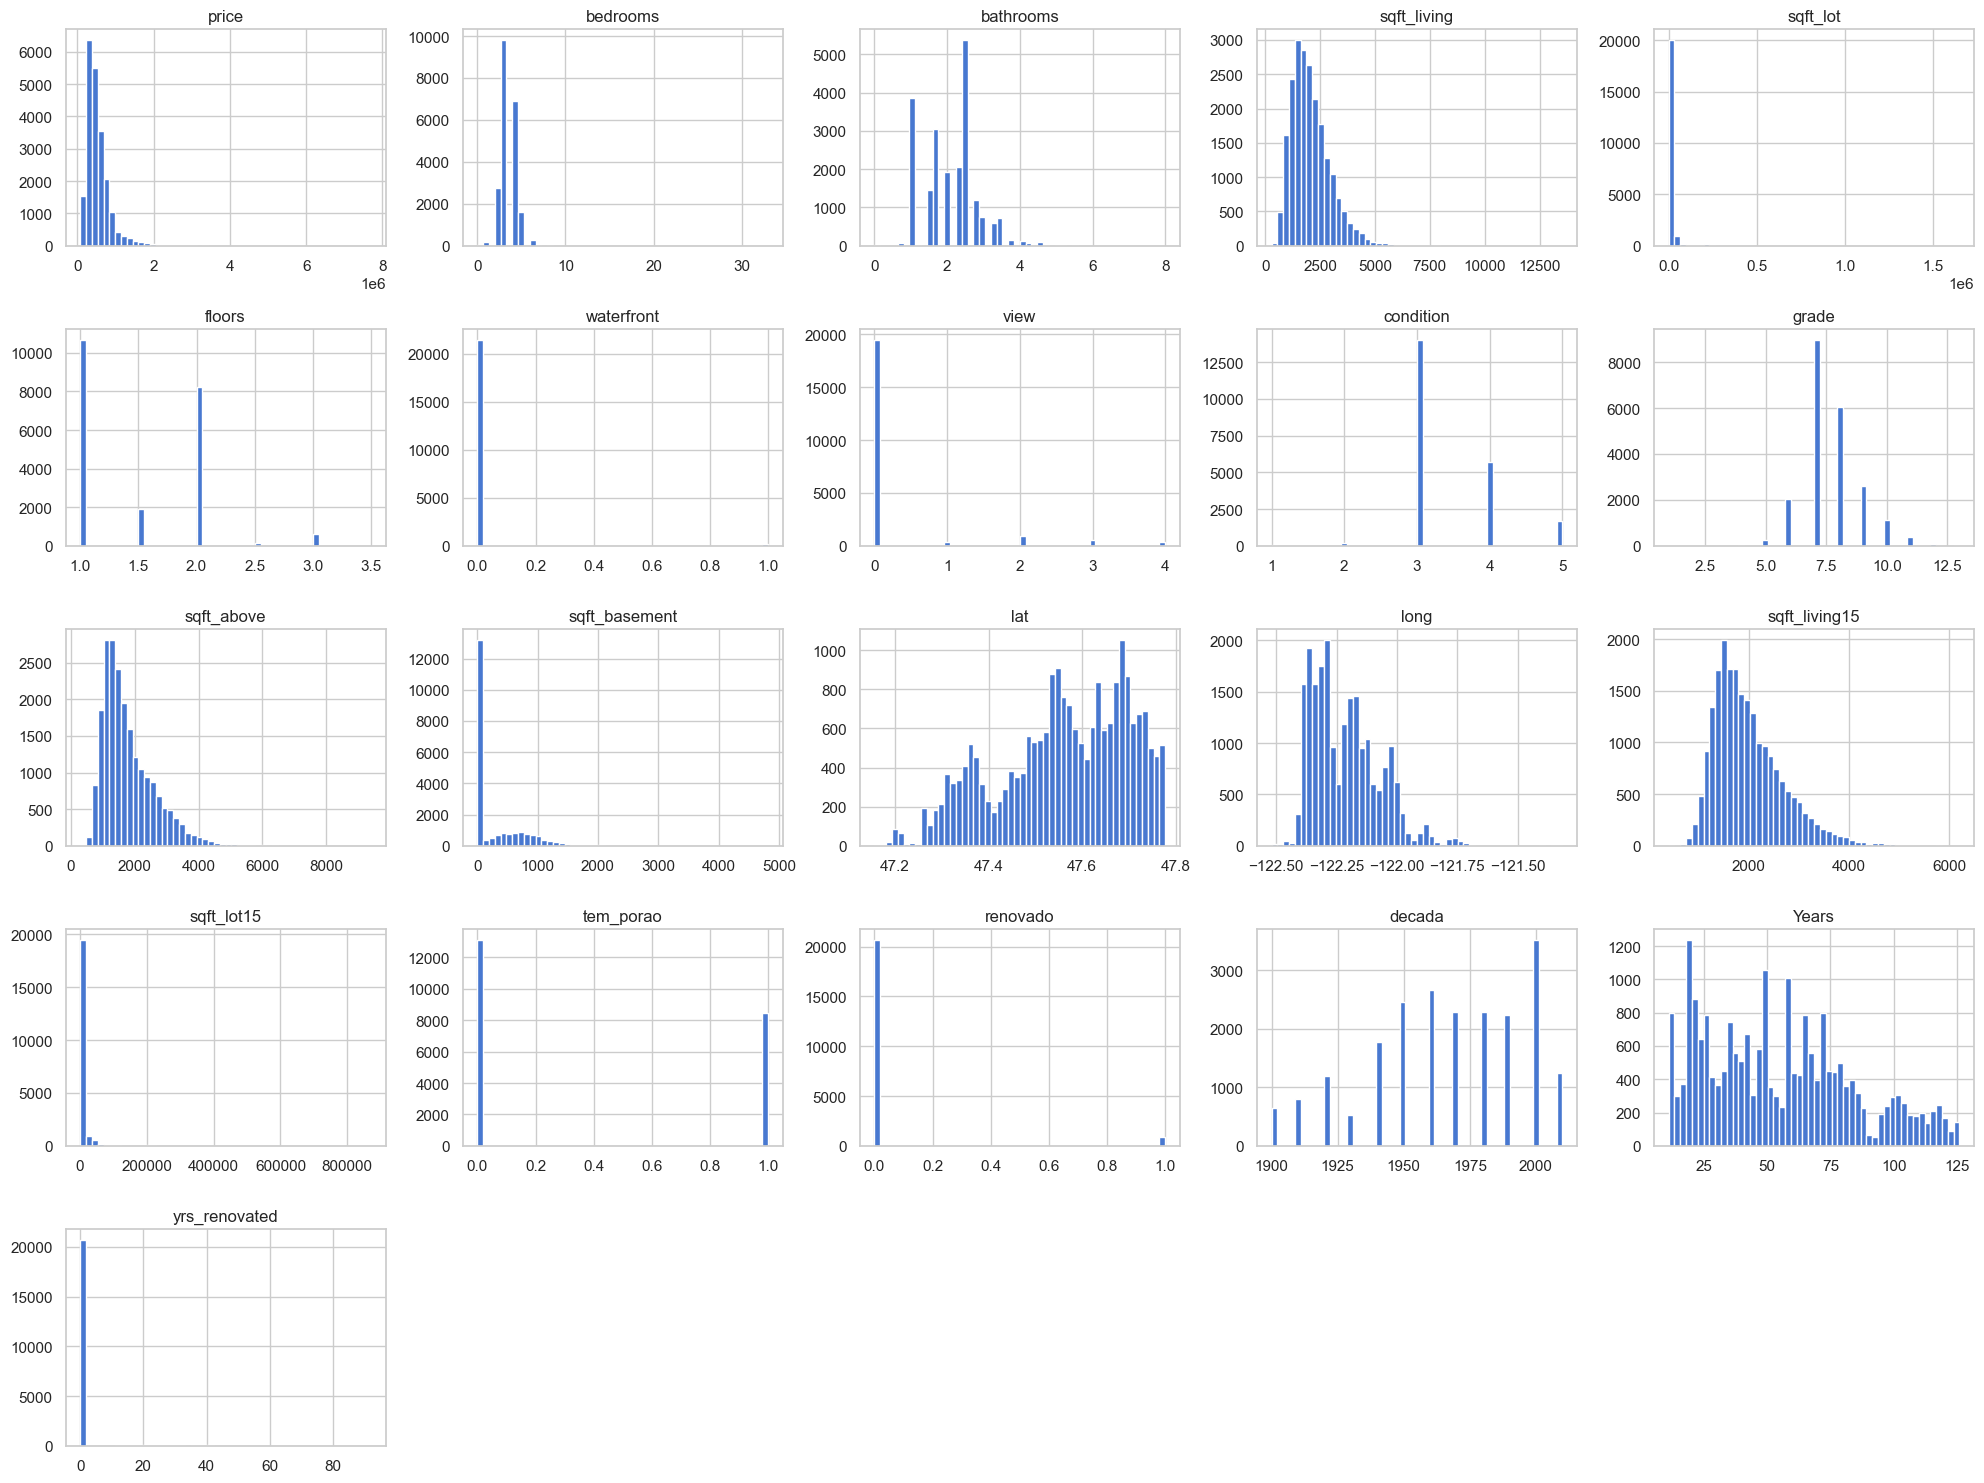

In [28]:
df.hist(bins = 50, figsize = (20,15))
save_fig("histogramas.png")
plt.show()

Salvando figura scatter_plot.png em imagens\scatter_plot.png


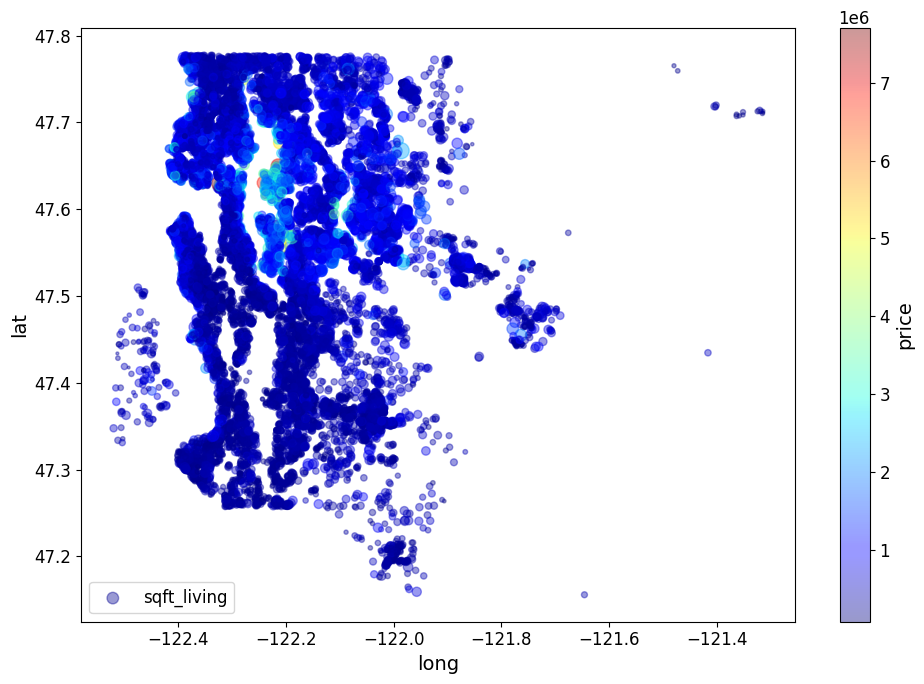

In [11]:
df.plot(kind = "scatter", x = "long", y = "lat", alpha = 0.4, s = df["sqft_living"]/100, label = "sqft_living", figsize = (10,7), c = "price", cmap = plt.get_cmap("jet"), colorbar = True)
save_fig("scatter_plot.png")
plt.show()

Salvando figura scatter_plot.png em imagens\scatter_plot.png


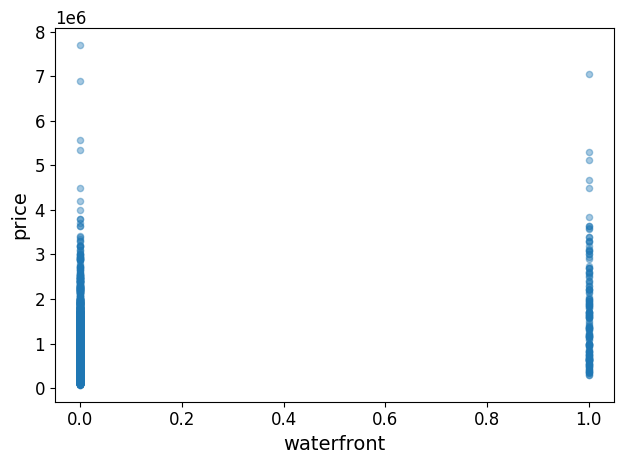

In [12]:
df.plot(kind = "scatter", x = "waterfront", y = "price", alpha = 0.4)
save_fig("scatter_plot.png")
plt.show()

In [13]:
!pip install geopandas contextily

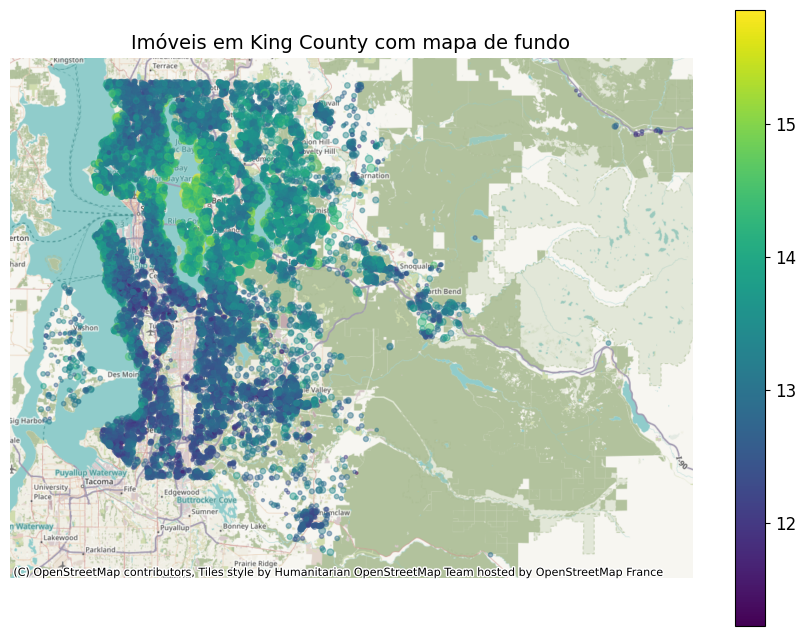

In [14]:
import pandas as pd
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
import numpy as np

df["log_price"] = np.log1p(df["price"])

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["long"], df["lat"]),
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

ax = gdf.plot(
    column="log_price",
    markersize=gdf["sqft_living"] / 200,
    alpha=0.45,
    cmap="viridis",
    legend=True,
    figsize=(11, 8)
)

cx.add_basemap(ax)

plt.title("Imóveis em King County com mapa de fundo")
plt.axis("off")
plt.show()